In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw3-task2.ipynb")

# Homework 3 - Task 2: Tree-Based Methods
## Predicting Water Potability Using Decision Trees and Random Forests

---


### Dataset

Access to safe drinking water is a fundamental public health concern. This dataset contains physicochemical measurements for 3,276 water samples, each labeled as potable or non-potable.

| Feature | Description |
|---|---|
| `ph` | pH value of water (0–14 scale) |
| `Hardness` | Capacity to precipitate soap (mg/L) |
| `Solids` | Total dissolved solids (ppm) |
| `Chloramines` | Amount of chloramines (ppm) |
| `Sulfate` | Amount of sulfates dissolved (mg/L) |
| `Conductivity` | Electrical conductivity (μS/cm) |
| `Organic_carbon` | Amount of organic carbon (ppm) |
| `Trihalomethanes` | Amount of trihalomethanes (μg/L) |
| `Turbidity` | Measure of light-emitting property (NTU) |

#### Response Variable

| Column | Description |
|---|---|
| `Potability` | Binary flag — `1` if water is safe to drink, `0` otherwise |


 **Note:** Several features contain missing values (`ph`, `Sulfate`, `Trihalomethanes`). You will handle these in the preprocessing step.

 This dataset comes from Kaggle and can be found [here](https://www.kaggle.com/datasets/uom190346a/water-quality-and-potability).

### Setup: Load Libraries

Run the cell below to import all required packages.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



### Step 1: Load the Data

Read `water_potability.csv` into a DataFrame. Preview the first few rows and confirm its shape.

In [3]:
df = pd.read_csv('water_potability.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


### Step 2: Explore the Data

Before modeling, examine the distribution of your response variable and the number of NAs. Understanding both will guide preprocessing decisions.

In [4]:
# Check total rows to ensure value counts accounts for NA
total_bin_val = len(df['Potability'])
total_bin_val

3276

In [5]:
# Return unique values in Potability column including NA
df['Potability'].value_counts(dropna=False)

Potability
0    1998
1    1278
Name: count, dtype: int64

### Step 3: Preprocess the Data

Three features have missing values. A simple approach for tree-based methods is to **impute with the column median**. Impute the missing values using `df.fillna()`.Store your cleaned dataframe in a variable called `df_clean`. 

After imputation, split the data 70/30 into training and test sets, stratifying on `Potability` to preserve the class ratio in both splits.Store your results in `X_train`, `X_test`, `y_train`, and `y_test`.

In [6]:
# Return column containing NA
df.isna().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [7]:
# Fill NA values in columns containing NA with their median 
df_clean = df

df_clean['ph'] = df['ph'].fillna(df['ph'].median())

df_clean['Sulfate'] = df['Sulfate'].fillna(df['Sulfate'].median())

df_clean['Trihalomethanes'] = df['Trihalomethanes'].fillna(df['Trihalomethanes'].median())

In [8]:
# Check if updated df has NA
df_clean.isna().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

In [9]:
feature_names = [
    "ph", "Hardness", "Solids", "Chloramines",
    "Sulfate", "Conductivity", "Organic_carbon", "Trihalomethanes", "Turbidity"]

In [10]:
# Obtain adequate predictor and response dimensions for 70/30
X = df_clean[feature_names]
y = df_clean['Potability']

In [13]:
# Split data into training and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [14]:
grader.check("q1")

q1 results: All test cases passed!

### Step 4: Fit a Single Classification Tree

Start with an **unpruned** classification tree (no constraints on depth or leaf size). This gives a baseline and illustrates the overfitting problem that ensemble methods address.

Fit `DecisionTreeClassifier` with only `random_state=42` set (all other parameters at defaults). Report the tree depth in a variable named `tree_depth`. Calculate both the train accuracy and the test accuracy, storing the train accuracy in a variable called`dt_unpruned_acc_train` and the test accuracy in a variable called `dt_unpruned_acc_test`. 

In [15]:
# Create decision tree with no depth limit
dt_unpruned = DecisionTreeClassifier(random_state=42)
dt_unpruned.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [16]:
# Return unpruned depth
tree_depth = dt_unpruned.get_depth()

# Calculate accuracy of test and training 
dt_unpruned_acc_train = accuracy_score(y_train, dt_unpruned.predict(X_train))

dt_unpruned_acc_test  = accuracy_score(y_test, dt_unpruned.predict(X_test))


print(f"Unpruned Tree Depth: {tree_depth}  Unpruned Training Accuracy: {dt_unpruned_acc_train} Unpruned Test Accuracy: {dt_unpruned_acc_test}")


Unpruned Tree Depth: 33  Unpruned Training Accuracy: 1.0 Unpruned Test Accuracy: 0.5808748728382502


In [17]:
grader.check("q2")

q2 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q1: How does the training accuracy and test accuracy differ? What does this mean about your model?**

The training accuracy is near perfect at 100% and the test accuracy is poor at around 50%. This indicates the model fit too perfectly to the training data (overfit) so now when it sees new data it tries assigning classes using very specific splits that only worked for the training data, not new data. On this test data it becomes inaccurate, it should have memorized the underlying pattern, not the overly training-specific splits.

<!-- END QUESTION -->

### Step 5: Tune Tree Depth with Cross-Validation

A fully grown tree memorizes the training data (better training accuracy, poor test accuracy). We need to find the right **depth** to prevent this. 

Using 5-fold cross-validation on the training set, compute mean CV accuracy for `max_depth` from 1 to 20. Identify the optimal depth using `np.argmax`, storing it in a variable called `optimal_depth`. Plot the CV Accuracy against the 20 different depths, adding a vertical line at the optimal depth. 

Best max_depth (5-fold CV): 7  (CV accuracy: 0.639)


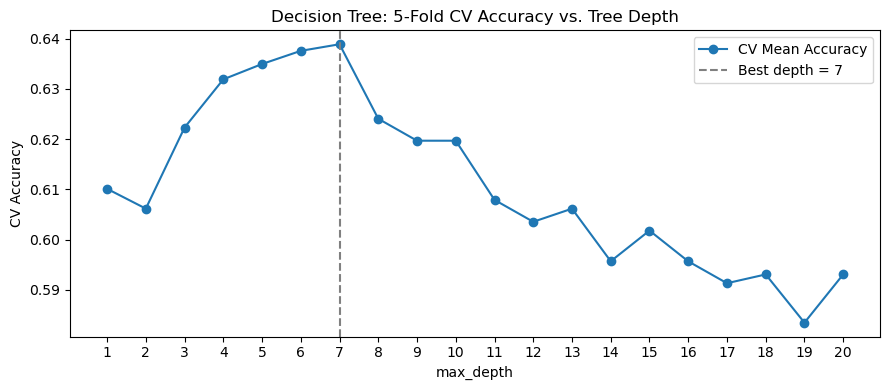

In [18]:
depths = range(1,21)
cv_means = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth = depth, random_state=42)
    scores = cross_val_score(dt, X_train, y_train, cv = 5, scoring = 'accuracy')
    cv_means.append(scores.mean())
cv_means = np.array(cv_means)
optimal_depth = list(depths)[np.argmax(cv_means)]

print(f"Best max_depth (5-fold CV): {optimal_depth}  (CV accuracy: {cv_means.max():.3f})")

plt.figure(figsize=(9, 4))
plt.plot(list(depths), cv_means, label='CV Mean Accuracy', marker='o')
plt.axvline(optimal_depth, color='gray', linestyle='--', label=f'Best depth = {optimal_depth}')
plt.xlabel('max_depth')
plt.ylabel('CV Accuracy')
plt.xticks(list(depths))
plt.title('Decision Tree: 5-Fold CV Accuracy vs. Tree Depth')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
grader.check("q3")

q3 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q2: What did cross fold validation find the optimal depth to be? Explain what these means in plain language.**

The cross fold validation found that the optimal depth is 7. This means having our decision tree with 7 levels maximizes the accuracy of our model. Having more levels than that could cause our model to overfit and become less accurate. 

<!-- END QUESTION -->

### Step 6: Fit the Tuned Decision Tree

Refit the decision tree using `optimal_depth` and evaluate on the held-out test set. Store the test accuracy in a variable called `acc_dt`. 

In [20]:
# Create decision tree with depth limit of 7
dt_opt = DecisionTreeClassifier(max_depth= optimal_depth, random_state=42)
dt_opt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=7, random_state=42)

In [21]:
# Calculate pruned tree accuracy on test 
acc_dt  = accuracy_score(y_test, dt_opt.predict(X_test))
print(f"Optimal Tree Depth Accuracy: {acc_dt}")

Optimal Tree Depth Accuracy: 0.6459816887080366


In [22]:
grader.check("q4")

q4 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q3: Did the accuracy on your tuned decision tree imrpove compared to your untuned tree? If so, why do you think it improved?**

Yes, the accuracy of my tuned decision tree improved compared to my untuned tree. It improved because it had a depth limit which stopped it from overfitting. Therefore, it remained generalizable and performed better on new data. 

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 7: Visualize the Decision Tree

Plot the tuned tree using `plot_tree`. Save the tree as an image to evaluate the results and answer **Q5**. 

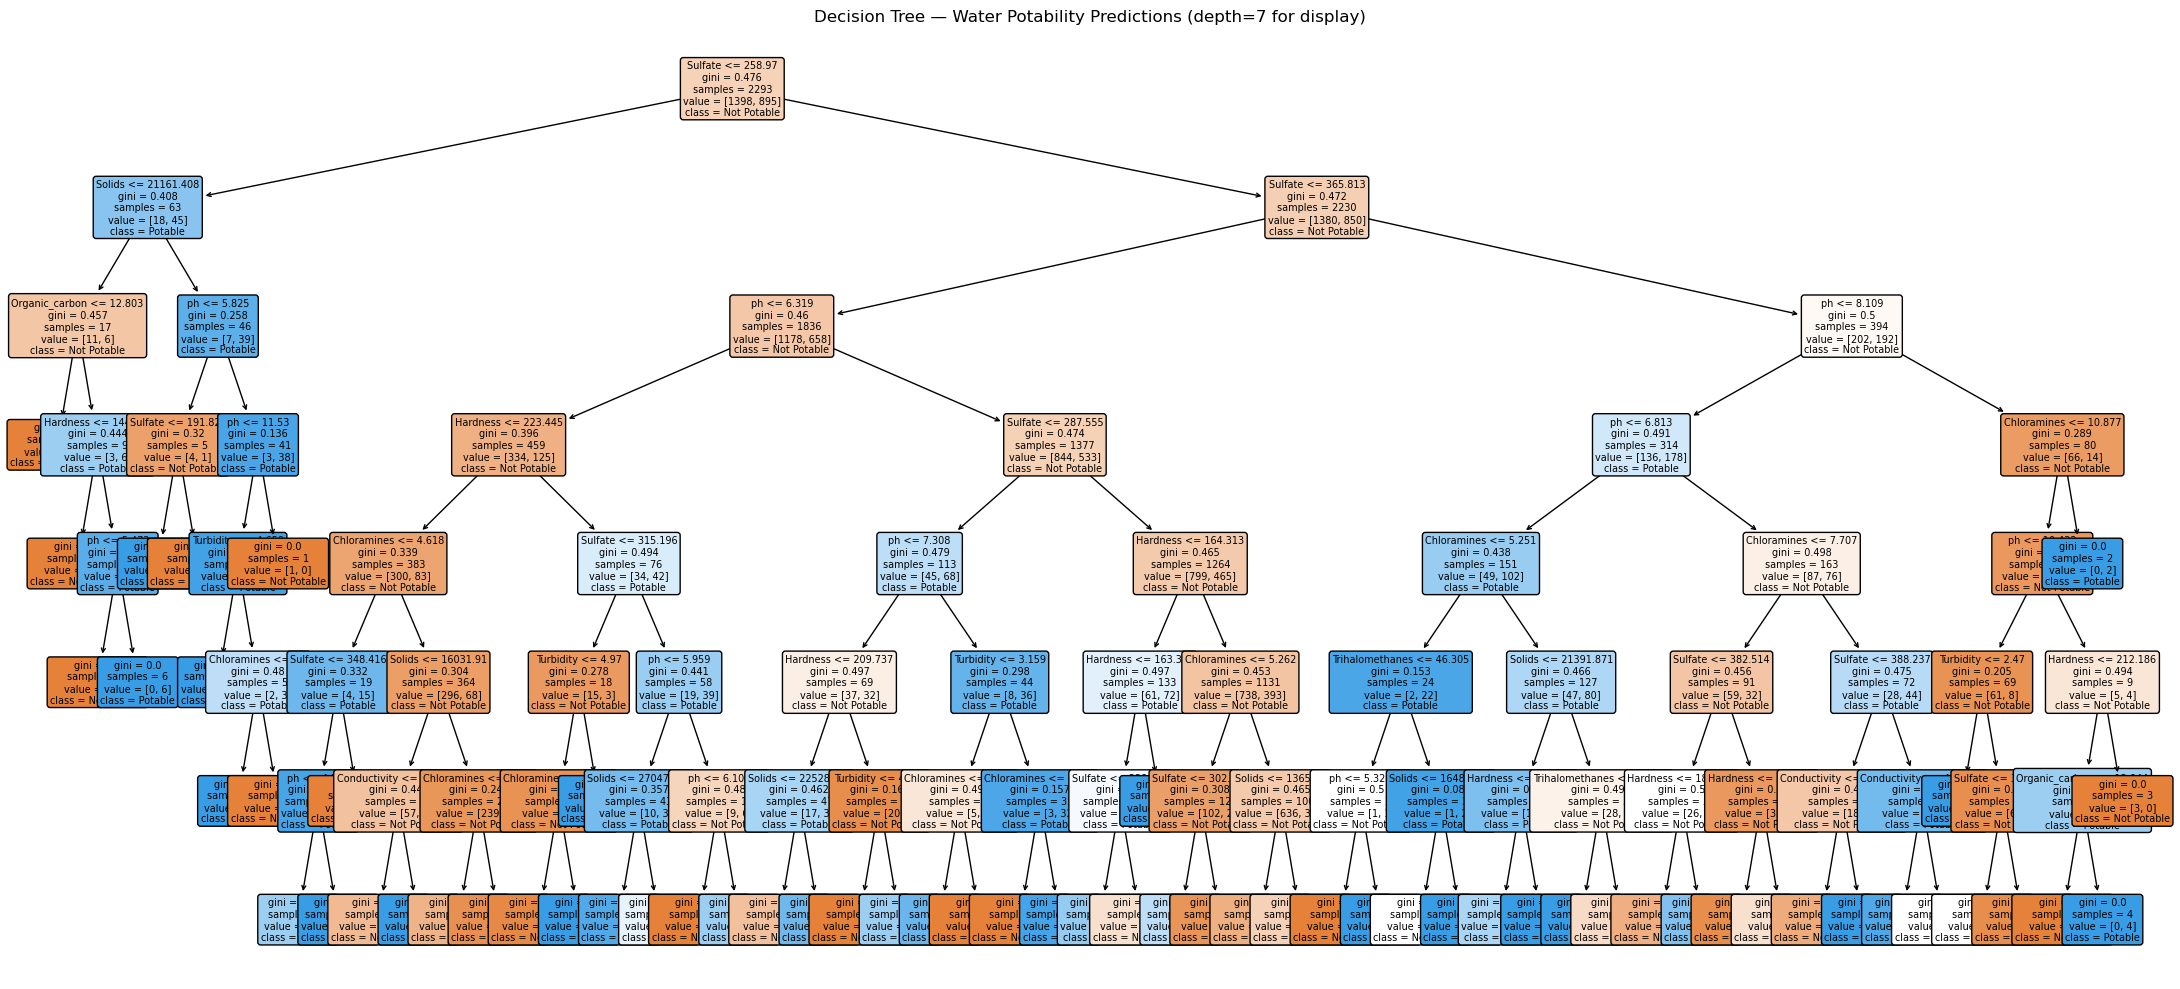

In [23]:
dt_viz = DecisionTreeClassifier(
    max_depth=optimal_depth, 
    random_state=42
)

dt_viz.fit(X_train, y_train)

plt.figure(figsize=(22, 10))
class_names = ['Not Potable', 'Potable']  # 0 first, 1 second
               
# Plot tree
plot_tree(dt_viz, feature_names=feature_names, class_names = class_names,
filled = True, rounded = True, fontsize = 7)
          
plt.title('Decision Tree — Water Potability Predictions (depth=7 for display)')
plt.tight_layout()
plt.show()

> **Q4: Examine the root node and first two levels of the tree. Which feature is used for the root split, and what threshold does it use? What does this tell you about that feature's relationship with potability? What is the Gini impurity at the root, and how does it change after the first split?**

Sulfate is used for the root split. Sulfate values less than or equal to 258.97 mean it follows the left branch path and more than 258.97 mean it follows the right branch. This tells me Sulfate levels are the most important predictor of water potability. The Gini impurity at the root is high at 0.476. After the first split the Gini index decreases for all intermediate notes. This indicates that there is more purity in the resulting classification after this split. 

<!-- END QUESTION -->

### Step 8: Random Forest

**Random forests** address the high variance of a single tree by fitting many trees on bootstrap samples of the training data and averaging their predictions. To further reduce correlation among the trees, at each split only a random subset of $m$ features is considered (by default sklearn uses $m = \lfloor\sqrt{p}\rfloor$ for classification).

Fit a `RandomForestClassifier`, called `rf` with `n_estimators=200`. Report the accuracy and store it in `acc_rf`. 

In [24]:

rf = RandomForestClassifier(
    n_estimators=200, max_features = 'sqrt', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

acc_rf  = accuracy_score(y_test,  y_pred_rf )

print(f"Random Forest test acc:   {acc_rf:.3f}")

Random Forest test acc:   0.661


In [25]:
grader.check("q5")

q5 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q5: Compare the test results of Decision Tree and Random Forest? Which performed beter? Why do you think this is?**

The Random Forest performed better, its accuracy was 0.661 while the decision tree's accuracy was 0.646. I believe this is the case because Random Tree creates many trees using bootstrapped data and averages their predictions. This reduces high variance that can be associated with the use of a single decision tree. 

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 9: Feature Importances

Both decision trees and random forests assign an **importance score** to each feature based on the total reduction in impurity (Gini) it produces across all splits. Random forest importances are averaged over all trees in the ensemble, making them more stable than a single tree's importances.

Create a bar plot showing the feature importances from the tuned decision tree and the random forest side by side. You can access the feature importants from the model wtih `model.feature_importances_`.

In [26]:
feat_imp_dt = pd.Series(dt_opt.feature_importances_, index=feature_names).sort_values(ascending=False)
feat_imp_rf = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

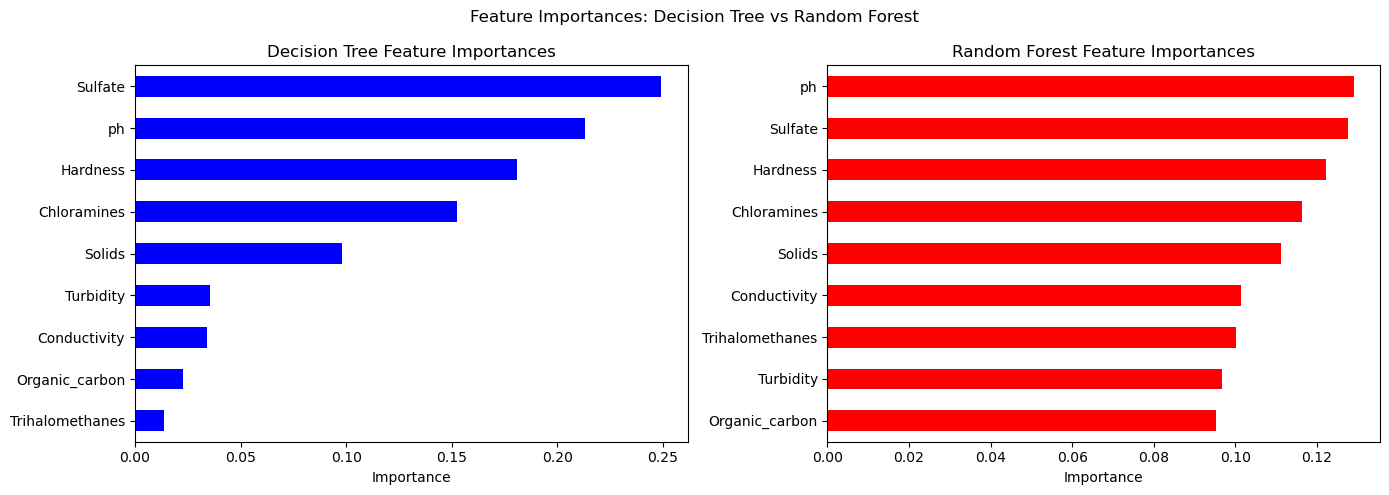

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

feat_imp_dt.sort_values().plot(kind='barh', color='blue', ax=axes[0])
axes[0].set_title('Decision Tree Feature Importances')
axes[0].set_xlabel('Importance')

feat_imp_rf.sort_values().plot(kind='barh', color='red', ax=axes[1])
axes[1].set_title('Random Forest Feature Importances')
axes[1].set_xlabel('Importance')

plt.suptitle('Feature Importances: Decision Tree vs Random Forest')
plt.tight_layout()
plt.show()

> **Q6: Do the decision tree and random forest agree on which features are most important? If they differ, why might a single tree's importances be less reliable than the random forest's? Which feature appears most important for predicting potability, and does that make physical sense?**

No, my Random Forest model and Decision Tree do not agree on which features are most important. The single tree's importance is less reliable because it used a single dataset to produce a tree model. My Random Forest model is more reliable because it averaged across multiple bootstrap datasets to determine splits and feature importance. Looking at Random Forest, it seems ph is the most important feature for predicting potability. This makes sense, ph of water can be a strong indicator of potability because dangerous and solvents that make water non-potable are associated with extreme (either too low or high) ph values. 

<!-- END QUESTION -->

### Step 10: Confusion Matrix

Create a confusion matrix for the random forest model using `ConfusionMatrixDisplay`. Label your response variable as `Not Potable`/ `Potable` in the confusion matrix (instead of `0`/`1`).

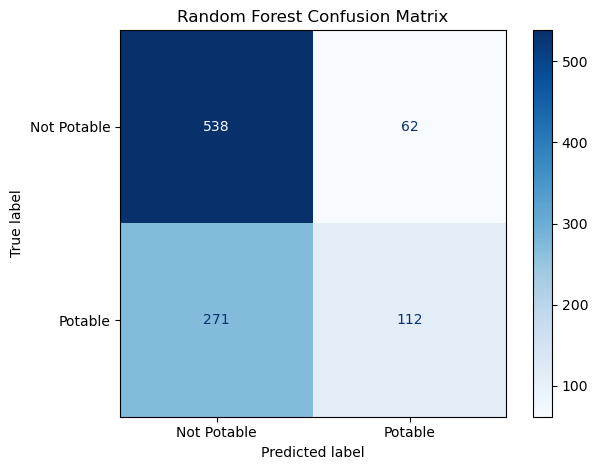

In [28]:
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Potable', 'Potable'])
disp.plot(cmap='Blues')

plt.title('Random Forest Confusion Matrix')
plt.tight_layout()
plt.show()

<!-- BEGIN QUESTION -->

> **Q7:** Report the results of the confusion matrix. How many false positives, true positives, false negatives, and true negatives did your model predict? Interpret what each of those 4 results means in the context of the data.

False Positives: 62
- My model classified 62 water samples as potable when in reality they were not potable. 

True Positives:112
- My model classified 112 water samples as potable and in reality they were potable. 

False Negatives: 271
- My model classified 271 water samples as non-potable when in reality they were potable. 

True Negatives: 538
- My model classified 538 water samples as non-potable and in reality they were non-potable. 

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 11: Model Comparison

Create a table or bar chart comparing test accuracy across all three models.

In [30]:
tree_model_names = ['Unpruned Decision Tree', 'Tuned Decision Tree', 'Random Forest']

In [32]:
# Accuracy table for Unpruned Decision Tree, Tuned Decision Tree, And Random Forest
tree_acc_tbl = pd.DataFrame({
    'Model': tree_model_names,
    'Accuracy': [dt_unpruned_acc_test, acc_dt, acc_rf]
})

print(tree_acc_tbl.to_string(index=False))


                 Model  Accuracy
Unpruned Decision Tree  0.580875
   Tuned Decision Tree  0.645982
         Random Forest  0.661241


> **Q8:** Which model achieved the highest test accuracy? Comparing the unpruned and tuned decision tree, how much did pruning improve accuracy? What does this tell you about overfitting in the unpruned tree?


Random forest achieved the highest test accuracy. Pruning increased the accuracy by 6.5%. This tells me that overfitting in the unpruned tree reduced model accuracy. 

---

Run the cell below to receive credit for autograded questions. 

In [35]:
grader.check_all()

q1 results: All test cases passed!

q2 results: All test cases passed!

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results: All test cases passed!